In [ ]:
#Using TF - IDF metho
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
df=pd.read_csv("spam.csv", encoding='latin-1')
df=df[['v1', 'v2']]
df.columns=['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
def clean_text(text):
    text=text.lower()  # convert to lowercase
    text=re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation & numbers
    return text

df['message']=df['message'].apply(clean_text)
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])

In [8]:
le=LabelEncoder()
y=le.fit_transform(df['label'])
print(y)

[0 0 1 ... 0 0 0]


In [9]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
model=MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [11]:
y_pred=model.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 1]


In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.968609865470852
Precision: 1.0
Recall: 0.7666666666666667
F1 Score: 0.8679245283018868


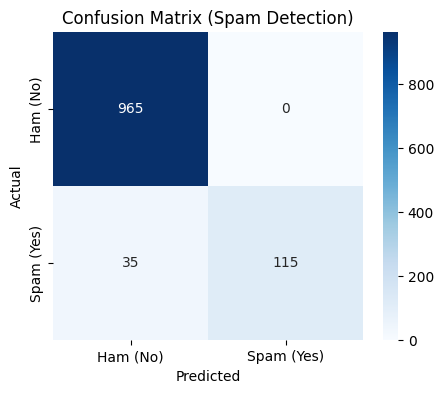

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Ham (No)', 'Spam (Yes)'],
            yticklabels=['Ham (No)', 'Spam (Yes)'],
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Spam Detection)")
plt.show()

In [14]:
feature_names=vectorizer.get_feature_names_out()
spam_indices=np.argsort(model.feature_log_prob_[1])[-10:]

print("Top words influencing Spam:")
for i in spam_indices:
    print(feature_names[i])

Top words influencing Spam:
reply
won
text
ur
stop
prize
mobile
claim
txt
free


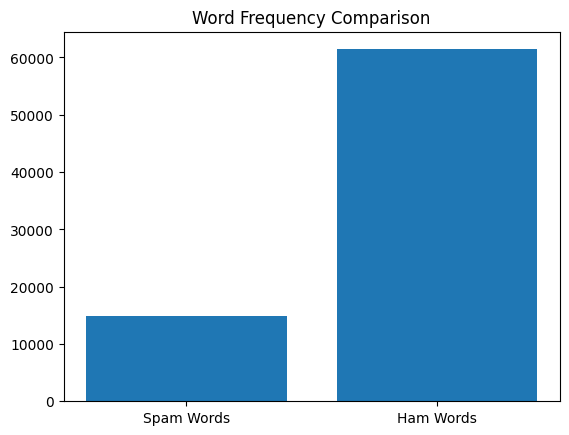

In [15]:
spam_messages = df[df['label'] == 'spam']['message']
ham_messages = df[df['label'] == 'ham']['message']

spam_vector = CountVectorizer().fit_transform(spam_messages)
ham_vector = CountVectorizer().fit_transform(ham_messages)

spam_counts = np.sum(spam_vector.toarray(), axis=0)
ham_counts = np.sum(ham_vector.toarray(), axis=0)

plt.bar(['Spam Words', 'Ham Words'], 
        [sum(spam_counts), sum(ham_counts)])
plt.title("Word Frequency Comparison")
plt.show()

In [16]:
misclassified = np.where(y_test != y_pred)

print("Some Misclassified Examples:\n")
for i in misclassified[0][:5]:
    print("Message:", df.iloc[i]['message'])
    print("Actual:", y_test[i], "Predicted:", y_pred[i])
    print("-----------")

Some Misclassified Examples:

Message: free entry in  a wkly comp to win fa cup final tkts st may  text fa to  to receive entry questionstd txt ratetcs apply overs
Actual: 1 Predicted: 0
-----------
Message: k tell me anything about you
Actual: 1 Predicted: 0
-----------
Message: gud mrng dear hav a nice day
Actual: 1 Predicted: 0
-----------
Message: there is os called ubandu which will run without installing in hard diskyou can use that os to copy the important files in system and give it to repair shop
Actual: 1 Predicted: 0
-----------
Message: would really appreciate if you call me just need someone to talk to
Actual: 1 Predicted: 0
-----------


In [17]:
model2 = MultinomialNB(alpha=0.1)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("New Accuracy:", accuracy_score(y_test, y_pred2))

New Accuracy: 0.9766816143497757
